# 🎯 Lab 2: Syntax & Semantics - Understanding Text Structure

We're going beyond individual words to understand how they work together. Think of it as moving from knowing vocabulary to understanding grammar and meaning.

## 📚 What You'll Learn
- How words relate to each other in sentences (syntax parsing)
- How to identify real-world entities in text (NER)
- How to represent words as numbers (word embeddings)
- How to find similar words automatically

In [ ]:
# Install all libraries used in this notebook
!pip install -q spacy nltk pandas numpy matplotlib seaborn scikit-learn plotly

# Download the spaCy English model (this is what was missing before,
# spacy alone does not ship with a language model)
!python -m spacy download en_core_web_sm


In [ ]:
import spacy
import nltk
from nltk.corpus import reuters
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter, defaultdict
from spacy import displacy

# Load the spaCy pipeline we just downloaded above
nlp = spacy.load("en_core_web_sm")

# Download the NLTK reuters corpus (used later for extra practice text)
nltk.download('reuters')


## 🌳 Section 1: Dependency Parsing - Understanding Sentence Structure

Think of a sentence like a family tree. Every word has relationships with other words - some are parents, some are children, some are siblings. Dependency parsing maps out these relationships!

fox-parse.svg

In [ ]:
sentences = [
    "The quick brown fox jumps over the lazy dog.",
    "Apple Inc. is planning to release a new iPhone model next year.",
]

def visualize_dependencies(text, title=""):
    doc = nlp(text)

    print(f"\n🌳 {title}")
    print(f"📝 Sentence: {text}")
    print("\n🔗 Dependency Relationships:")
    print(f"{'Word':<15} {'POS':<8} {'Dependency':<12} {'Head':<15} {'Children'}")
    print("-" * 70)

    for token in doc:
        children = [child.text for child in token.children]
        children_str = ", ".join(children) if children else "None"
        print(f"{token.text:<15} {token.pos_:<8} {token.dep_:<12} {token.head.text:<15} {children_str}")

    return doc

# Analyze our example sentences
for i, sentence in enumerate(sentences, 1):
    doc = visualize_dependencies(sentence, f"Example {i}")

    # Let's also show the main subject and verb
    subjects = [token.text for token in doc if token.dep_ in ["nsubj", "nsubjpass"]]
    verbs = [token.text for token in doc if token.pos_ == "VERB" and token.dep_ == "ROOT"]

    print(f"🎯 Main subject(s): {subjects}")
    print(f"🎯 Main verb(s): {verbs}")
    print("=" * 70)

### 🎯 Mini Exercise 1.1
Create your own sentence and analyze its structure! Try making it complex with multiple clauses.

In [ ]:
# 🏃‍♀️ Your turn! Create a complex sentence
your_sentence = "Although the project was challenging, the team completed it successfully and learned a lot."

# Analyze your sentence
your_doc = visualize_dependencies(your_sentence, "Your Sentence Analysis")

# Show dependency parse visualization
print("📌 Dependency Parsing Visualization:")
displacy.render(your_doc, style="dep", jupyter=True)

# Challenge: Can you identify all the noun phrases in your sentence?
noun_phrases = [chunk.text for chunk in your_doc.noun_chunks]
print(f"\n🔍 Noun phrases found: {noun_phrases}")


## 🏷️ Section 2: Named Entity Recognition (NER) - Finding Real-World Things

Named Entity Recognition (NER) is like having a super-smart highlighter that can identify people, places, organizations, dates, and more in text. It's incredibly useful for information extraction!

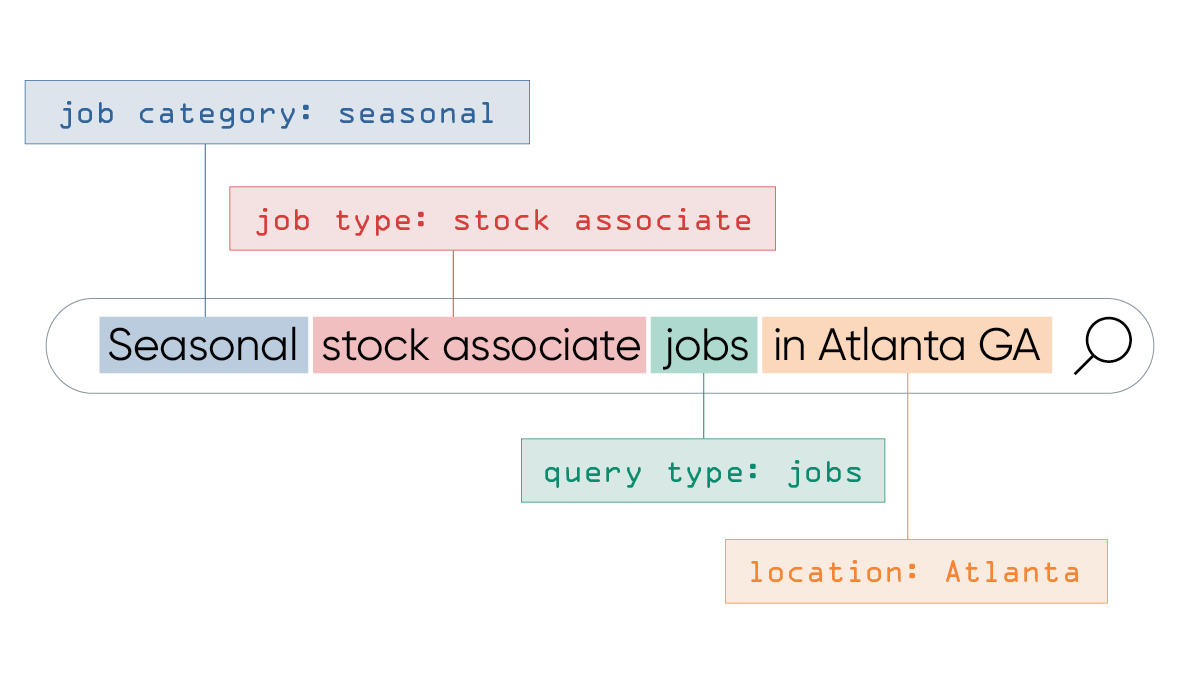

In [ ]:
# Let's analyze some news-like text with many entities
news_text = """
Apple CEO Tim Cook announced today that the company will invest $50 billion in
artificial intelligence research over the next five years. The announcement was
made at the World Economic Forum in Davos, Switzerland, on January 15th, 2024.
Microsoft and Google are expected to follow suit with similar investments.
The European Union has already allocated €10 billion for AI research through
its Horizon Europe program, which runs until 2027.
"""

def analyze_entities(text, title=""):
    """
    Extract and categorize named entities from text
    """
    doc = nlp(text)

    print(f"\n🏷️ {title}")
    print(f"📝 Text: {text[:100]}...")

    if doc.ents:
        print(f"\n🎯 Found {len(doc.ents)} named entities:")
        print(f"{'Entity':<25} {'Type':<15} {'Description'}")
        print("-" * 60)

        entity_counts = defaultdict(list)
        for ent in doc.ents:
            entity_counts[ent.label_].append(ent.text)
            description = spacy.explain(ent.label_)
            print(f"{ent.text:<25} {ent.label_:<15} {description}")

        print(f"\n📊 Entity type summary:")
        for entity_type, entities in entity_counts.items():
            print(f"   {entity_type}: {len(entities)} entities ({', '.join(set(entities))})")
    else:
        print("❌ No entities found!")

    return doc

# Analyze our news text
news_doc = analyze_entities(news_text, "News Article Analysis")

### 🎯 Mini Exercise 2.1
Find a news article online and analyze its entities! What types of information can you extract?

In [ ]:
your_news = """
Paste your news article text here! Try to find something with lots of
people, places, organizations, and dates.
"""

# Analyze your news text
your_news_doc = analyze_entities(your_news, "Your News Analysis")

## 🔢 Section 3: Word Embeddings - Words as Numbers

Now for the magic! We're going to represent words as vectors (lists of numbers) that capture their meaning. Words with similar meanings will have similar numbers.

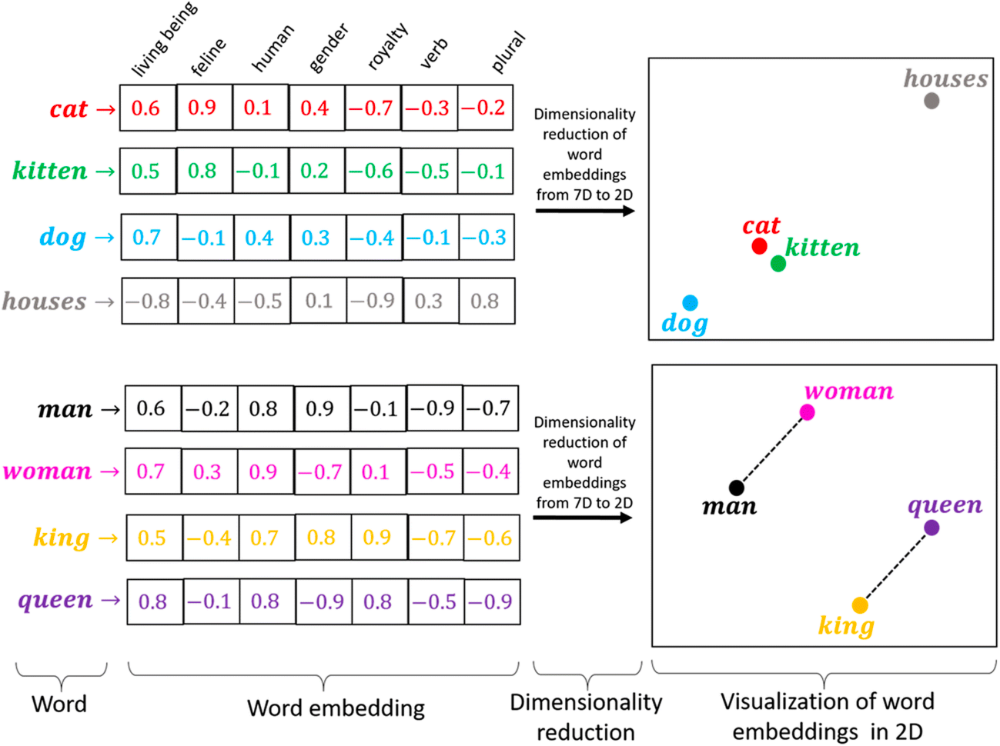

In [ ]:
def explore_word_similarity(words):
    """
    Compare word similarities using embeddings and visualize them
    """
    print("🔢 Word Embedding Analysis")
    print("=" * 50)

    # Get word vectors
    word_vectors = {}
    for word in words:
        doc = nlp(word)
        if doc.has_vector:
            word_vectors[word] = doc.vector
            print(f"✅ {word}: vector dimension {doc.vector.shape[0]}")
        else:
            print(f"❌ {word}: no vector available")

    # Create similarity matrix
    keys = list(word_vectors.keys())
    sim_matrix = np.zeros((len(keys), len(keys)))

    for i, word1 in enumerate(keys):
        for j, word2 in enumerate(keys):
            sim_matrix[i, j] = nlp(word1).similarity(nlp(word2))

    # Print similarity matrix in text
    print(f"\n🎯 Similarity Matrix:")
    print(f"{'Word':<12}", end="")
    for word in keys:
        print(f"{word:<10}", end="")
    print()
    for i, word1 in enumerate(keys):
        print(f"{word1:<12}", end="")
        for j in range(len(keys)):
            print(f"{sim_matrix[i, j]:.3f}     ", end="")
        print()

    # 🔍 Visualize similarity matrix as heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(sim_matrix, xticklabels=keys, yticklabels=keys,
                annot=True, cmap="Blues", fmt=".2f", square=True)
    plt.title("🔍 Word Similarity Matrix", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return word_vectors

# Test with different word groups
print("🚗 Transportation words:")
transport_words = ["car", "bicycle", "airplane", "train", "boat", "motorcycle"]
transport_vectors = explore_word_similarity(transport_words)

print("\n🍎 Food words:")
food_words = ["apple", "banana", "pizza", "sandwich", "cake", "salad"]
food_vectors = explore_word_similarity(food_words)

print("\n😊 Emotion words:")
emotion_words = ["happy", "sad", "angry", "excited", "calm", "nervous"]
emotion_vectors = explore_word_similarity(emotion_words)

In [ ]:
def find_similar_words(target_word, vocabulary, top_n=5):
    """
    Find the most similar words to a target word
    """
    target_doc = nlp(target_word)
    if not target_doc.has_vector:
        print(f"❌ No vector available for '{target_word}'")
        return []

    similarities = []
    for word in vocabulary:
        if word != target_word:
            word_doc = nlp(word)
            if word_doc.has_vector:
                similarity = target_doc.similarity(word_doc)
                similarities.append((word, similarity))

    # Sort by similarity (highest first)
    similarities.sort(key=lambda x: x[1], reverse=True)

    print(f"🔍 Words most similar to '{target_word}':")
    for i, (word, sim) in enumerate(similarities[:top_n], 1):
        print(f"   {i}. {word} (similarity: {sim:.3f})")

    return similarities[:top_n]


all_vocabulary = [
    # Animals
    "dog", "cat", "elephant", "lion", "tiger", "bird", "fish", "horse",
    # Technology
    "computer", "phone", "internet", "software", "robot", "artificial", "intelligence",
    # Nature
    "tree", "flower", "ocean", "mountain", "river", "forest", "sunshine",
    # Actions
    "run", "walk", "jump", "dance", "sing", "write", "read", "think"
]

test_words = ["dog", "computer", "happy", "run"]
for word in test_words:
    print()
    find_similar_words(word, all_vocabulary, top_n=3)
    print("-" * 40)

## 📊 Section 4: Visualizing Word Embeddings

Let's create a 2D map of our word embeddings so we can see how words cluster together!

In [ ]:
def visualize_word_embeddings(words, title="Word Embeddings Visualization"):
    """
    Create a 2D visualization of word embeddings using PCA
    """
    # Get vectors for words that have embeddings
    valid_words = []
    vectors = []

    for word in words:
        doc = nlp(word)
        if doc.has_vector:
            valid_words.append(word)
            vectors.append(doc.vector)

    if len(vectors) < 2:
        print("❌ Need at least 2 words with vectors for visualization")
        return

    # Reduce dimensionality to 2D using PCA
    pca = PCA(n_components=2)
    vectors_2d = pca.fit_transform(vectors)

    # Create the plot
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1],
                         c=range(len(valid_words)), cmap='tab20',
                         s=100, alpha=0.7, edgecolors='black')

    # Add word labels
    for i, word in enumerate(valid_words):
        plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    plt.title(f'📊 {title}', fontsize=16, fontweight='bold')
    plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
    plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"✅ Visualized {len(valid_words)} words")
    print(f"📊 PCA explained {sum(pca.explained_variance_ratio_):.1%} of the variance")

# Visualize our different word categories
print("🎨 Visualizing mixed vocabulary:")
mixed_words = transport_words + food_words + emotion_words
visualize_word_embeddings(mixed_words, "Mixed Word Categories")

# Create a more interesting mix
interesting_mix = [
    "king", "queen", "man", "woman",  # Gender relationships
    "paris", "france", "london", "england",  # Geography
    "good", "better", "best", "bad", "worse", "worst",  # Comparisons
    "cat", "kitten", "dog", "puppy"  # Animals and their young
]

print("\n🎨 Visualizing interesting word relationships:")
visualize_word_embeddings(interesting_mix, "Word Relationships")